# Neural Network Model - Multi-Layer Perceptron

**Purpose:** Apply feedforward neural network with backpropagati8) for electricity demand forecasting.

**Model Type:** Multi-Layer Percepte 8)
- Feedforward neural network with hidden layers
- Non-linear activation functions (ReLU)
- Backpropagation for weight updates
- Demonstrates deep learning cm course

**Implementation:** Scikit-learn MLPRegressor
- Architecture: 3 hidden layers (128, 64, 32 neurons)
- Activation: ReLU
- Solver: Adam optimizer
- Early stopping to prevent overfitting

**Dataset:** Same master dataset (31 features, 108,888 records)

**Expected Performance:** RMSE ~400-450 MW
- Should be comparable to Linear Regression
- Captures non-linear patterns through hidden layersaster training than SVR

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Loading master dataset...")
df = pd.read_csv("../../../02_Datasets/processed/master_dataset_complete.csv",
                 parse_dates=['DateTime', 'Date'])

# Feature preparation
exclude_cols = ['DateTime', 'Date', 'Holiday_Name']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Ontario Demand', 'Market Demand']]
target_col = 'Ontario Demand'

print(f"✓ Data loaded: {df.shape}")
print(f"Features: {len(feature_cols)}")

Loading master dataset...
✓ Data loaded: (109056, 36)
Features: 31


In [6]:
print("Preparing data...")

# Create X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with missing lag features
mask_valid = df['Demand_Lag_168h'].notna()
X = X[mask_valid]
y = y[mask_valid]

# Fill remaining missing values
X = X.fillna(method='ffill').fillna(method='bfill')

print(f"✓ Data prepared: {X.shape}")

# Split data (same as previous models)
n = len(X)
train_size = int(0.77 * n)
val_size = int(0.08 * n)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f"\nData split:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Val:   {len(X_val):,} samples")
print(f"  Test:  {len(X_test):,} samples")

# Scale features (required for neural networks)
print(f"\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled")

Preparing data...
✓ Data prepared: (108888, 31)

Data split:
  Train: 83,843 samples
  Val:   8,711 samples
  Test:  16,334 samples

Scaling features...
✓ Features scaled


In [8]:
print("Training Neural Network (Multi-Layer Perceptron)...")
print("Architecture: 3 hidden layers (128 → 64 → 32 neurons)")
print("="*70)

start_time = time.time()

# Initialize MLP with 3 hidden layers
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,  # L2 regularization
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)

# Train model
model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

print(f"✓ Model trained in {train_time:.2f} seconds")
print(f"  Iterations completed: {model.n_iter_}")
if model.best_loss_ is not None:
    print(f"  Best validation loss: {model.best_loss_:.2f}")

# Make predictions
print("\nMaking predictions...")
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:,.2f} MW")
    print(f"  MAE:  {mae:,.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("NEURAL NETWORK RESULTS:")
print(f"  Test RMSE: {test_metrics['RMSE']:,.2f} MW")
print(f"  Test R²:   {test_metrics['R2']:.4f}")
print(f"  Training Time: {train_time:.2f} seconds")
print("="*70)

Training Neural Network (Multi-Layer Perceptron)...
Architecture: 3 hidden layers (128 → 64 → 32 neurons)
✓ Model trained in 185.09 seconds
  Iterations completed: 102

Making predictions...

Training Set:
  RMSE: 167.35 MW
  MAE:  126.95 MW
  R²:   0.9950
  MAPE: 0.82%

Validation Set:
  RMSE: 185.85 MW
  MAE:  142.83 MW
  R²:   0.9925
  MAPE: 0.91%

Test Set:
  RMSE: 203.92 MW
  MAE:  156.74 MW
  R²:   0.9928
  MAPE: 0.97%

NEURAL NETWORK RESULTS:
  Test RMSE: 203.92 MW
  Test R²:   0.9928
  Training Time: 185.09 seconds


In [9]:
# Save results
results_summary = {
    'Model': 'Neural Network (MLP)',
    'Train_RMSE': train_metrics['RMSE'],
    'Train_R2': train_metrics['R2'],
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_R2': test_metrics['R2'],
    'Test_MAE': test_metrics['MAE'],
    'Test_MAPE': test_metrics['MAPE'],
    'Training_Time_Seconds': train_time
}

results_df = pd.DataFrame([results_summary])
comparison_file = '../../../04_Presentation/model_results/06_comparison/model_comparison.csv'
existing_results = pd.read_csv(comparison_file)
updated_results = pd.concat([existing_results, results_df], ignore_index=True)
updated_results.to_csv(comparison_file, index=False)

print("✓ Neural Network results saved!")

✓ Neural Network results saved!


Creating Neural Network visualizations...


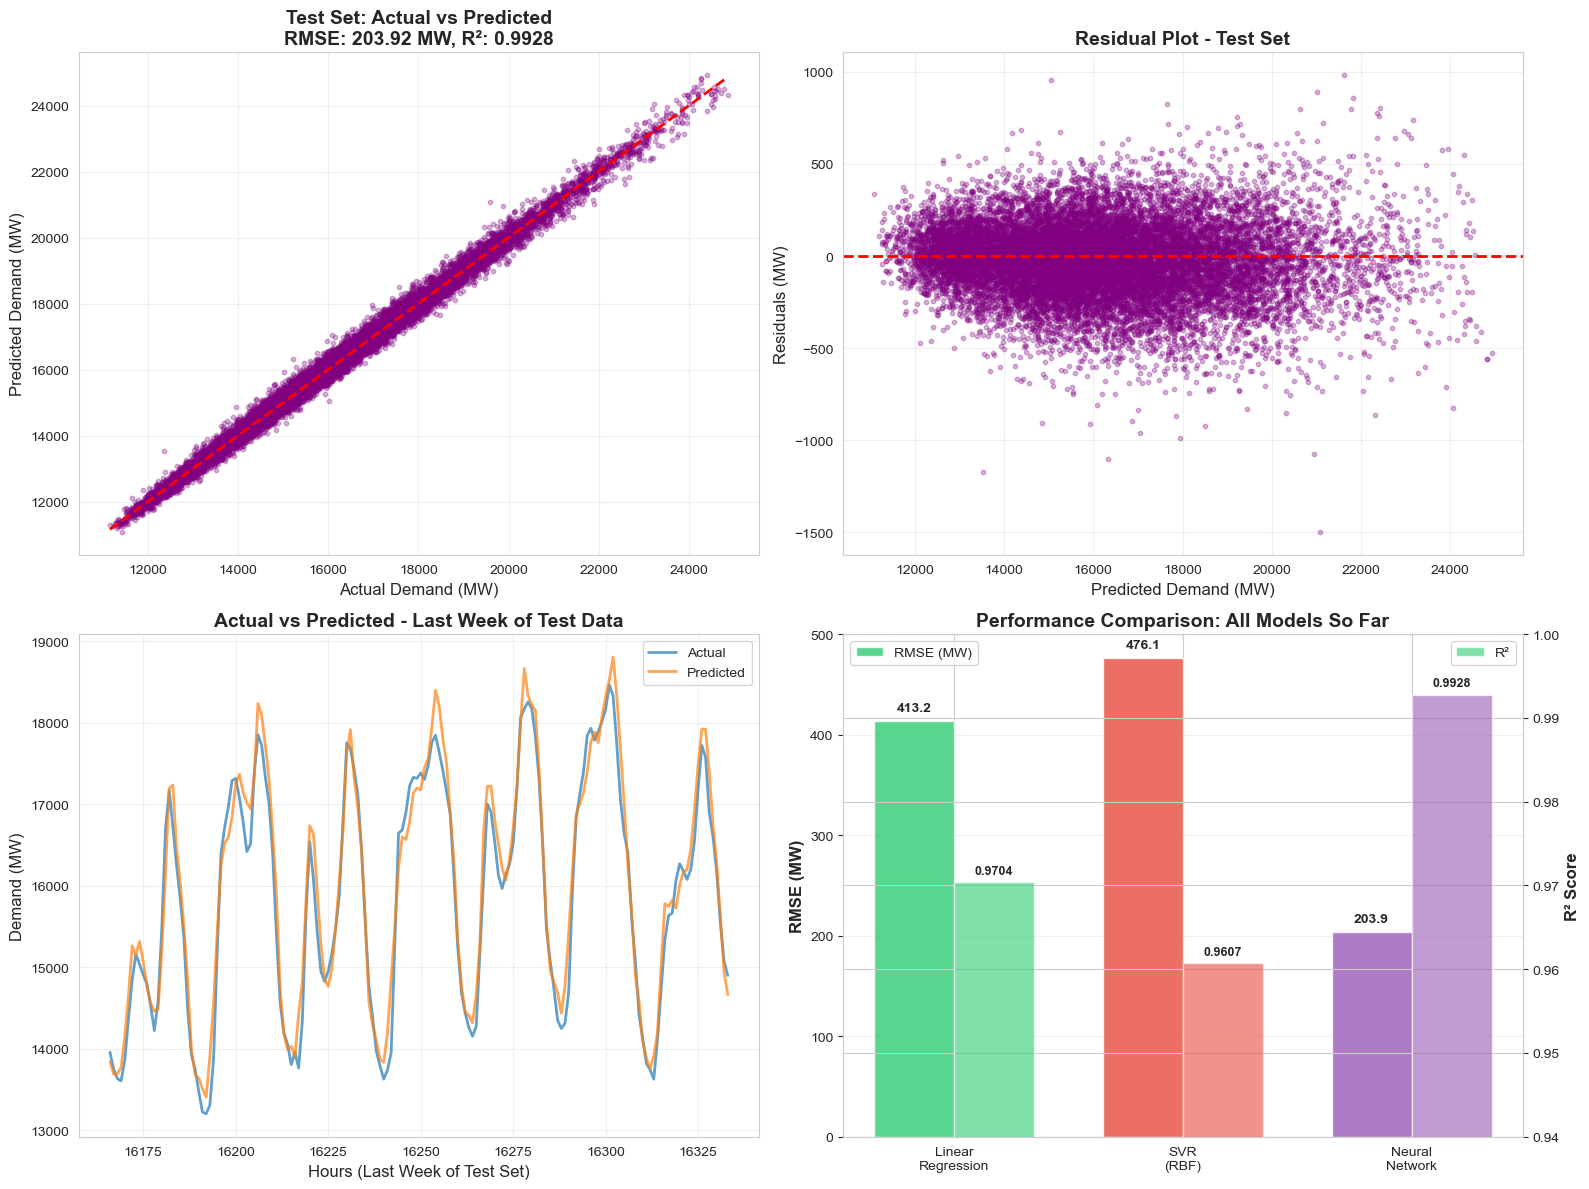


✓ Neural Network visualizations created and saved!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating Neural Network visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot - Test Set Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='purple')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Demand (MW)', fontsize=12)
ax1.set_ylabel('Predicted Demand (MW)', fontsize=12)
ax1.set_title(f'Test Set: Actual vs Predicted\nRMSE: {test_metrics["RMSE"]:.2f} MW, R²: {test_metrics["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Residuals plot
ax2 = axes[0, 1]
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.3, s=10, color='purple')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Demand (MW)', fontsize=12)
ax2.set_ylabel('Residuals (MW)', fontsize=12)
ax2.set_title('Residual Plot - Test Set', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Time series comparison (last week)
ax3 = axes[1, 0]
sample_size = 168  # 1 week
sample_indices = range(len(y_test) - sample_size, len(y_test))
ax3.plot(sample_indices, y_test.iloc[-sample_size:].values, label='Actual', linewidth=2, alpha=0.7)
ax3.plot(sample_indices, y_test_pred[-sample_size:], label='Predicted', linewidth=2, alpha=0.7)
ax3.set_xlabel('Hours (Last Week of Test Set)', fontsize=12)
ax3.set_ylabel('Demand (MW)', fontsize=12)
ax3.set_title('Actual vs Predicted - Last Week of Test Data', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Model comparison (Linear Reg vs SVR vs Neural Network)
ax4 = axes[1, 1]
models = ['Linear\nRegression', 'SVR\n(RBF)', 'Neural\nNetwork']
rmse_values = [413.25, 476.05, test_metrics['RMSE']]
r2_values = [0.9704, 0.9607, test_metrics['R2']]
colors = ['#2ecc71', '#e74c3c', '#9b59b6']

x = np.arange(len(models))
width = 0.35

bars1 = ax4.bar(x - width/2, rmse_values, width, label='RMSE (MW)', color=colors, alpha=0.8)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, r2_values, width, label='R²', color=colors, alpha=0.6)

ax4.set_ylabel('RMSE (MW)', fontsize=12, fontweight='bold')
ax4_twin.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax4.set_title('Performance Comparison: All Models So Far', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models)
ax4.set_ylim([0, 500])
ax4_twin.set_ylim([0.94, 1.0])
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (rmse, r2) in enumerate(zip(rmse_values, r2_values)):
    ax4.text(i - width/2, rmse + 10, f'{rmse:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax4_twin.text(i + width/2, r2 + 0.001, f'{r2:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/03_neural_network/performance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Neural Network visualizations created and saved!")

Creating Neural Network-specific visualizations...


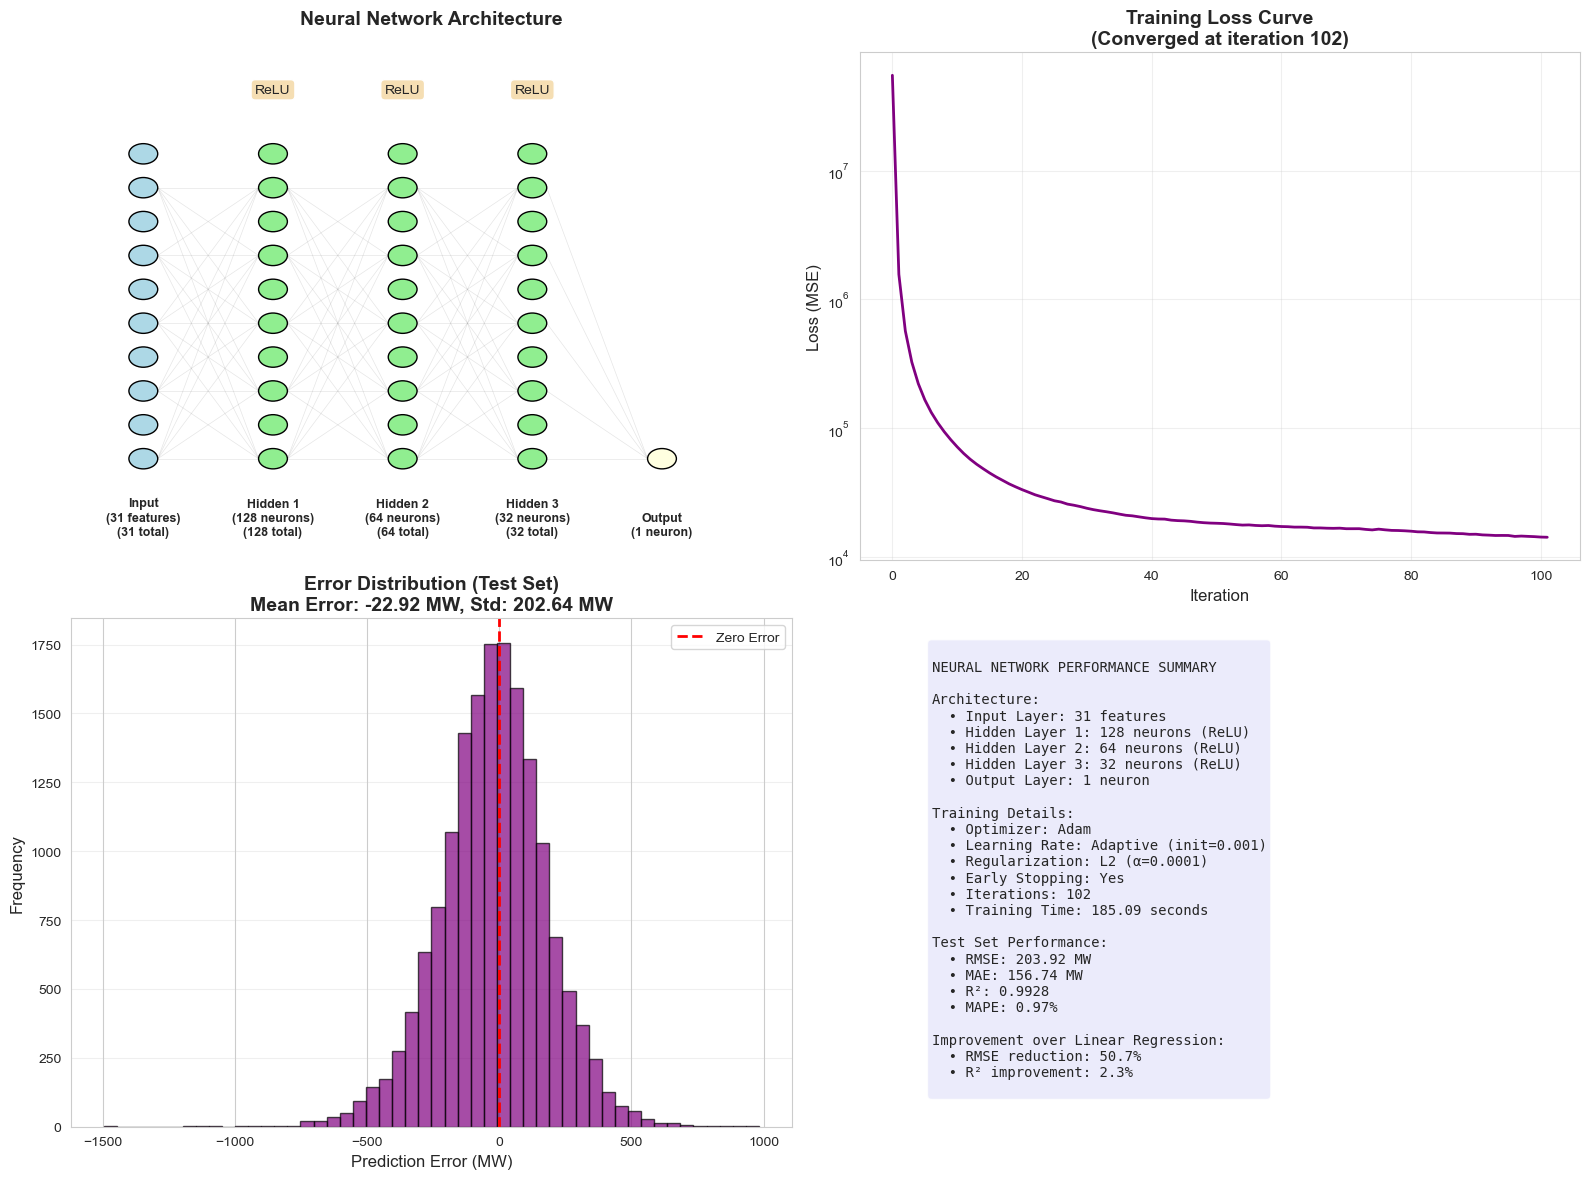


✓ Neural Network architecture visualizations created!


In [11]:
print("Creating Neural Network-specific visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Network Architecture Diagram
ax1 = axes[0, 0]
ax1.axis('off')
ax1.set_title('Neural Network Architecture', fontsize=14, fontweight='bold', pad=20)

# Draw network layers
layer_sizes = [31, 128, 64, 32, 1]
layer_names = ['Input\n(31 features)', 'Hidden 1\n(128 neurons)', 'Hidden 2\n(64 neurons)', 
               'Hidden 3\n(32 neurons)', 'Output\n(1 neuron)']
layer_colors = ['lightblue', 'lightgreen', 'lightgreen', 'lightgreen', 'lightyellow']

v_spacing = 0.15
h_spacing = 0.18
layer_positions = [0.1 + i * h_spacing for i in range(len(layer_sizes))]

# Draw nodes and connections
for i, (size, name, color, x_pos) in enumerate(zip(layer_sizes, layer_names, layer_colors, layer_positions)):
    # Limit display to max 10 nodes per layer for visualization
    display_size = min(size, 10)
    y_positions = np.linspace(0.2, 0.8, display_size)
    
    # Draw nodes
    for y_pos in y_positions:
        circle = plt.Circle((x_pos, y_pos), 0.02, color=color, ec='black', zorder=4)
        ax1.add_patch(circle)
    
    # Draw connections to next layer (simplified - not all connections)
    if i < len(layer_sizes) - 1:
        next_display_size = min(layer_sizes[i + 1], 10)
        next_y_positions = np.linspace(0.2, 0.8, next_display_size)
        for y1 in y_positions[::2]:  # Sample connections
            for y2 in next_y_positions[::2]:
                ax1.plot([x_pos + 0.02, layer_positions[i + 1] - 0.02], 
                        [y1, y2], 'gray', alpha=0.2, linewidth=0.5, zorder=1)
    
    # Layer labels
    if size > 10:
        label = f"{name}\n({size} total)"
    else:
        label = name
    ax1.text(x_pos, 0.05, label, ha='center', fontsize=9, fontweight='bold')

# Add activation function labels
ax1.text(0.28, 0.92, 'ReLU', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
ax1.text(0.46, 0.92, 'ReLU', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
ax1.text(0.64, 0.92, 'ReLU', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# 2. Training Loss Curve (if available)
ax2 = axes[0, 1]
if hasattr(model, 'loss_curve_'):
    ax2.plot(model.loss_curve_, linewidth=2, color='purple')
    ax2.set_xlabel('Iteration', fontsize=12)
    ax2.set_ylabel('Loss (MSE)', fontsize=12)
    ax2.set_title(f'Training Loss Curve\n(Converged at iteration {model.n_iter_})', 
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
else:
    ax2.text(0.5, 0.5, 'Loss curve not available', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# 3. Prediction Error Distribution
ax3 = axes[1, 0]
errors = y_test - y_test_pred
ax3.hist(errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.set_xlabel('Prediction Error (MW)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(f'Error Distribution (Test Set)\nMean Error: {errors.mean():.2f} MW, Std: {errors.std():.2f} MW', 
              fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Model Performance Summary
ax4 = axes[1, 1]
ax4.axis('off')

summary_text = f"""
NEURAL NETWORK PERFORMANCE SUMMARY

Architecture:
  • Input Layer: 31 features
  • Hidden Layer 1: 128 neurons (ReLU)
  • Hidden Layer 2: 64 neurons (ReLU)  
  • Hidden Layer 3: 32 neurons (ReLU)
  • Output Layer: 1 neuron

Training Details:
  • Optimizer: Adam
  • Learning Rate: Adaptive (init=0.001)
  • Regularization: L2 (α=0.0001)
  • Early Stopping: Yes
  • Iterations: {model.n_iter_}
  • Training Time: {train_time:.2f} seconds

Test Set Performance:
  • RMSE: {test_metrics['RMSE']:.2f} MW
  • MAE: {test_metrics['MAE']:.2f} MW
  • R²: {test_metrics['R2']:.4f}
  • MAPE: {test_metrics['MAPE']:.2f}%

Improvement over Linear Regression:
  • RMSE reduction: {((413.25 - test_metrics['RMSE'])/413.25*100):.1f}%
  • R² improvement: {((test_metrics['R2'] - 0.9704)/0.9704*100):.1f}%
"""

ax4.text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top', 
         family='monospace', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/03_neural_network/nn_architecture_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Neural Network architecture visualizations created!")

Analyzing Neural Network feature importance using permutation importance...
Computing permutation importance (this may take 1-2 minutes)...
✓ Feature importance calculated


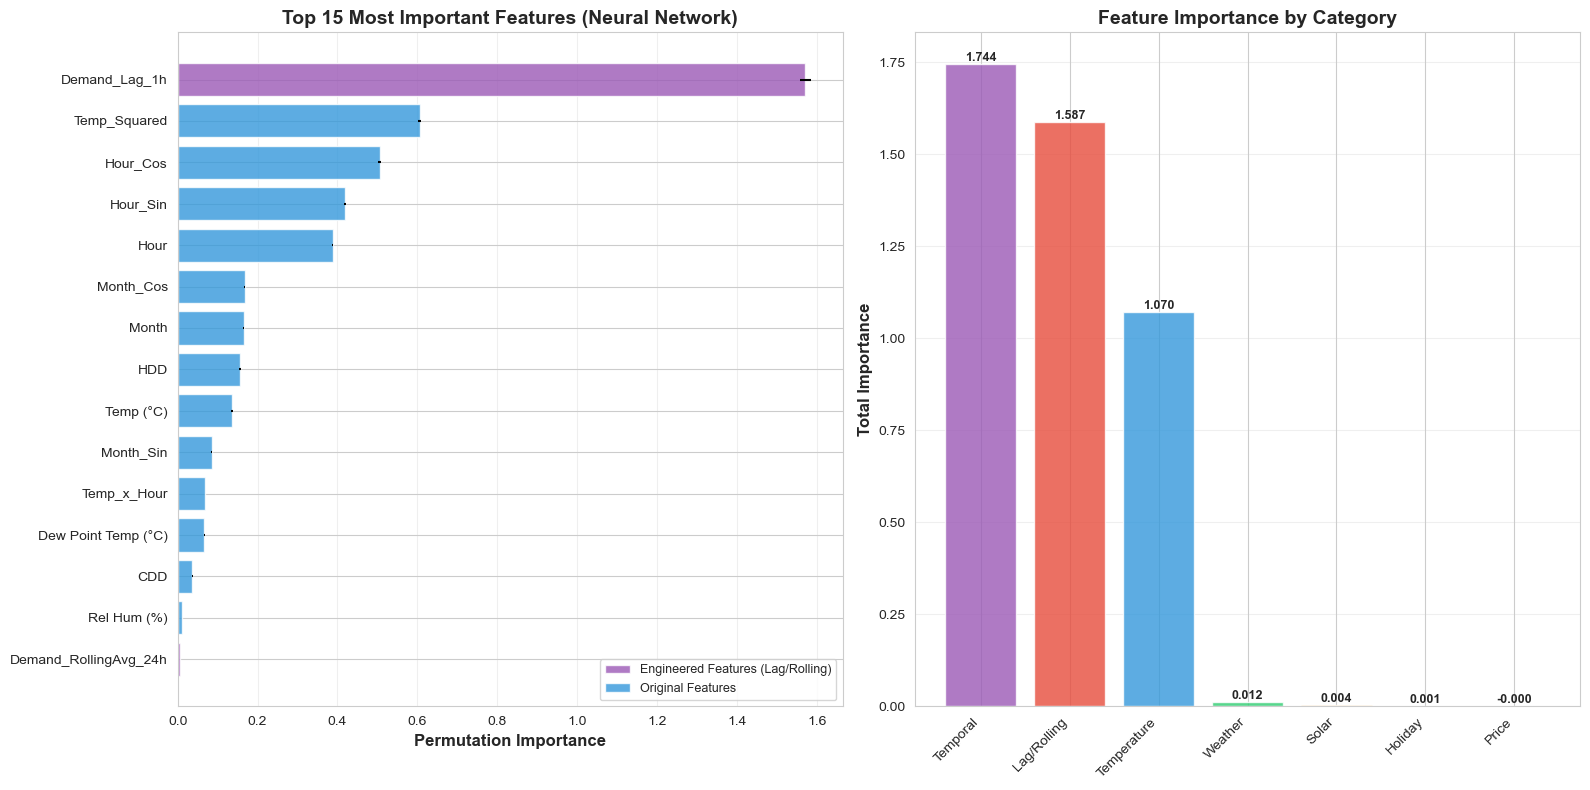


✓ Feature importance visualization created!

Top 5 Most Important Features:
  14. Demand_Lag_1h: 1.5707
  22. Temp_Squared: 0.6054
  24. Hour_Cos: 0.5058
  23. Hour_Sin: 0.4194
  1. Hour: 0.3882


In [12]:
print("Analyzing Neural Network feature importance using permutation importance...")

from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
# This shows which features, when shuffled, hurt performance the most
print("Computing permutation importance (this may take 1-2 minutes)...")

perm_importance = permutation_importance(
    model, X_test_scaled, y_test, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

# Get feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("✓ Feature importance calculated")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Top 15 features
ax1 = axes[0]
top_features = feature_importance_df.head(15)
colors = ['#9b59b6' if 'Lag' in f or 'Rolling' in f else '#3498db' for f in top_features['Feature']]

bars = ax1.barh(range(len(top_features)), top_features['Importance'], 
                xerr=top_features['Std'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['Feature'], fontsize=10)
ax1.set_xlabel('Permutation Importance', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Most Important Features (Neural Network)', 
              fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', alpha=0.8, label='Engineered Features (Lag/Rolling)'),
    Patch(facecolor='#3498db', alpha=0.8, label='Original Features')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# Plot 2: Feature importance by category
ax2 = axes[1]

# Categorize features
def categorize_feature(feature_name):
    if 'Lag' in feature_name or 'Rolling' in feature_name:
        return 'Lag/Rolling'
    elif 'Temp' in feature_name or 'HDD' in feature_name or 'CDD' in feature_name:
        return 'Temperature'
    elif feature_name in ['Hour', 'Month', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 
                          'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos']:
        return 'Temporal'
    elif feature_name in ['HOEP']:
        return 'Price'
    elif feature_name in ['GHI', 'DNI', 'DHI']:
        return 'Solar'
    elif feature_name == 'IsHoliday':
        return 'Holiday'
    else:
        return 'Weather'

feature_importance_df['Category'] = feature_importance_df['Feature'].apply(categorize_feature)
category_importance = feature_importance_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)

colors_cat = ['#9b59b6', '#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#95a5a6', '#34495e']
bars = ax2.bar(range(len(category_importance)), category_importance.values, 
               color=colors_cat[:len(category_importance)], alpha=0.8)
ax2.set_xticks(range(len(category_importance)))
ax2.set_xticklabels(category_importance.index, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Total Importance', fontsize=12, fontweight='bold')
ax2.set_title('Feature Importance by Category', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, category_importance.values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/03_neural_network/feature_importance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance visualization created!")
print(f"\nTop 5 Most Important Features:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")